# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

## **Edición 2025**


----

# Trabajo práctico entregable - parte 2


Trabajaremos con la base de datos de `melb_data` presentada a continuación.

In [1]:
import matplotlib.pyplot as plt
import numpy
import pandas
from sklearn.preprocessing import OneHotEncoder

import seaborn
seaborn.set_context('talk')

In [2]:
# Acá deberían leer el conjunto de datos que ya tienen.
melb_df = pandas.read_csv(
    'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv')
melb_df[:3]

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0


## Ejercicio 1: Encoding

1. Seleccionar todas las filas y columnas del conjunto de datos, **excepto** `BuildingArea` y `YearBuilt`.

2. Aplicar una codificación One-hot encoding a cada fila, para las variables categóricas. Si lo consideran necesario, pueden volver a reducir el número de categorías únicas.

Algunas opciones:
  1. Utilizar `OneHotEncoder` junto con el parámetro `categories` para las variables categóricas y luego usar `numpy.hstack` para concatenar el resultado con las variables numéricas.
  2. `DictVectorizer` con algunos pasos de pre-proceso previo.

Recordar también que el atributo `pandas.DataFrame.values` permite acceder a la matriz de numpy subyacente a un DataFrame.


Del entregable anterior, recordamos que Landsize tenía unos valores extremos en la cola derecha que introducirían mucho ruido en la imputación por KNN y la generación de PCAs, asi que como primer paso, filtramos este campo eliminando el percentil 99.

También, como vamos a dropear un par de filas, leemos BuildingArea y YearBuilt en este paso, para conservar los índices para despues poder matchear correctamente las columas (de todas formas estas columnas no las tocamos hasta la imputación)

In [3]:
# Elegimos las columnas relevantes
interesting_cols = [
  'Rooms', 'Type', 'Price', 'Method', 'SellerG', 'Distance',
  'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize',
  'CouncilArea', 'Lattitude', 'Longtitude', 'Regionname', 'Propertycount', 'YearBuilt', 'BuildingArea'
]

# Leemos el dataframe
df_encoded = pandas.read_csv(
    'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv',
    usecols=interesting_cols)

# Eliminamos los valores por encima del percentil 99 de 'Landsize'
upper = df_encoded['Landsize'].quantile(0.99)
df_encoded = df_encoded[df_encoded['Landsize'] <= upper]

# Tomamos las columnas categóricas a codificar
categorical_cols = ['Type', 'SellerG','Method', 'CouncilArea', 'Regionname']

categories_list = []
for category in categorical_cols: #Por alguna razón el OneHotEncoder pide que si una columna tiene NaN, estos aparezcan al último
  unique_cats = df_encoded[category].unique()
  # Separate NaN from other values
  nan_values = unique_cats[pandas.isna(unique_cats)]
  non_nan_values = unique_cats[~pandas.isna(unique_cats)]
  # Concatenate non-NaN values and NaN values (if any)
  sorted_cats = numpy.concatenate((non_nan_values, nan_values))
  categories_list.append(sorted_cats)

# Codificamos con OneHotEncoder
# Creamos el encoder, tomamos 25 cat_max para no tener una matriz muy grande
encoder = OneHotEncoder(categories=categories_list, max_categories=25, handle_unknown='ignore', sparse_output=False) # Use sparse=False to get a dense array
# Entrenamos y transformamos
X_cat = encoder.fit_transform(df_encoded[categorical_cols])

# Guardamos los nombres de las nuevas columnas
new_columns = encoder.get_feature_names_out(categorical_cols)

Notemos que no utilizamos "Address" como columna categórica ya que al ser la dirección del lugar, van a ser distintas para todos. Por lo tanto, al hacer el encoding estaríamos agregando muchas columnas sobre algo que probablemente no nos de mucha información. Para la fecha sucede algo similar. Por lo tanto, desestimamos estas 2 columnas.

Asimismo, decidimos no usar la columna 'Suburb' porque su valor tiene una relación 1 a 1 con la columna 'Propertycount'.

Por otro lado, al crear el encoder tomamos como máximo 25 categorías (las 25 con mayor frecuencia) para cada columna, con el fin de que la matriz no crezca exponencialmente y poder realizar la imputación más tarde sin problema.

In [4]:
# Podemos, para visualización, hacer un dataframe que tenga solamente
# las columnas categóricas codificadas
name_columns = encoder.get_feature_names_out(categorical_cols)
# get_feature_names_out da el nombre de todas las categorías de cada columna
cat_ecoded_df = pandas.DataFrame(X_cat, columns=name_columns)
cat_ecoded_df.sample(5)

,Type_h,Type_u,Type_t,SellerG_Biggin,SellerG_Nelson,SellerG_Jellis,SellerG_Greg,SellerG_Marshall,SellerG_Brad,SellerG_Barry,...,CouncilArea_nan,CouncilArea_infrequent_sklearn,Regionname_Northern Metropolitan,Regionname_Western Metropolitan,Regionname_Southern Metropolitan,Regionname_Eastern Metropolitan,Regionname_South-Eastern Metropolitan,Regionname_Eastern Victoria,Regionname_Northern Victoria,Regionname_Western Victoria
8291,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
10230,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5843,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4706,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
9046,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


## Ejercicio 2: Imputación por KNN

En el teórico se presentó el método `IterativeImputer` para imputar valores faltantes en variables numéricas. Sin embargo, los ejemplos presentados sólo utilizaban algunas variables numéricas presentes en el conjunto de datos. En este ejercicio, utilizaremos la matriz de datos codificada para imputar datos faltantes de manera más precisa.

1. Agregue a la matriz obtenida en el punto anterior las columnas `YearBuilt` y `BuildingArea`.
2. Aplique una instancia de `IterativeImputer` con un estimador `KNeighborsRegressor` para imputar los valores de las variables. ¿Es necesario estandarizar o escalar los datos previamente?
3. Realice un gráfico mostrando la distribución de cada variable antes de ser imputada, y con ambos métodos de imputación.

In [5]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import MinMaxScaler

Ahora, podemos pasar a aplicar una instancia de `IterativeImputer` con un estimador `KNeighborsRegressor` para imputar los valores de las variables. Es recomendable escalar o estandarizar los datos ya que el estimador se basa en distancia (ya que busca a los vecinos más cercanos). Escalar los datos hace que no tengamos columnas con escalas muy distintas entre sí y entonces no predominen las columnas con valores más grandes en el cálculo de la distancia.

Por lo tanto, vamos a escalar los datos. Para eso, podemos usar `MinMaxScaler` que es un método de sklearn para escalar los datos entre 0 y 1.

Otro dato a tener en cuenta basado en el entregable anterior, latitud y longitud están ingresados en distintos formatos (distinta cantidad de dígitos en números enteros, y números decimales), por lo que aplicamos un proceso de estandarización previo a usarlos.

In [6]:
# Preproceso sobre la latitud y longitud
def int_with_fixed_integer_digits(value: numpy.float64, int_digits: int) -> numpy.float64:
    s = str(value).replace('.', '')
    if len(s) <= int_digits:
        return float(s)
    integer_part = s[:int_digits]
    decimal_part = s[int_digits:]
    return float(f"{integer_part}.{decimal_part}")

df_encoded['Lattitude'] = df_encoded['Lattitude'].apply(lambda x: int_with_fixed_integer_digits(x, 3))
df_encoded['Longtitude'] = df_encoded['Longtitude'].apply(lambda x: int_with_fixed_integer_digits(x, 3))

# Como vamos a usar KNN, primero escalamos las columnas numéricas
numerical_cols = ['Rooms', 'Price', 'Distance', 'Bedroom2', 'Bathroom', 'Car', 'Lattitude', 'Longtitude', 'Propertycount']

# Definimos el scaler
scaler = MinMaxScaler()
# Entrenamos y transformamos
X_num = scaler.fit_transform(df_encoded[numerical_cols])

# Los datos procesados van a ser la concatenación de las categóricas
# codificadas y las numéricas escaladas
X_processed = numpy.hstack([X_cat, X_num])

# Y ahora, agregamos las variables que vamos a imputar
encoded_scaled_df = pandas.DataFrame(
    data=numpy.hstack([X_processed, df_encoded[['YearBuilt','BuildingArea']]]),
    columns=list(new_columns) + numerical_cols + ['YearBuilt','BuildingArea'])

# Y vamos a eliminar el percentil 1 y 99 para 'YearBuilt' y 'BuildingArea'
# Calcular límites de percentil 1 y 99
lower_yb = encoded_scaled_df['YearBuilt'].quantile(0.01)
upper_yb = encoded_scaled_df['YearBuilt'].quantile(0.99)

lower_ba = encoded_scaled_df['BuildingArea'].quantile(0.01)
upper_ba = encoded_scaled_df['BuildingArea'].quantile(0.99)

# Filtrar todo
encoded_scaled_df = encoded_scaled_df[
    ((encoded_scaled_df['YearBuilt'] >= lower_yb) | encoded_scaled_df['YearBuilt'].isna()) &
    ((encoded_scaled_df['YearBuilt'] <= upper_yb) | encoded_scaled_df['YearBuilt'].isna()) &
    ((encoded_scaled_df['BuildingArea'] >= lower_ba) | encoded_scaled_df['BuildingArea'].isna()) &
    ((encoded_scaled_df['BuildingArea'] <= upper_ba) | encoded_scaled_df['BuildingArea'].isna())
]

# Imprimimos la cantidad de datos nulos previo a la imputación
print("La cantidad de datos nulos en la columna YearBuilt previo a la imputación es: ", encoded_scaled_df['YearBuilt'].isna().sum())
print("La cantidad de datos nulos en la columna BuildingArea previo a la imputación es: ", encoded_scaled_df['BuildingArea'].isna().sum())

# Guardamos los datos antes de hacer el knn para luego graficar
original = encoded_scaled_df[['YearBuilt', 'BuildingArea']].copy(deep=True)

# Copiamos el dataframe
mice_encoded_scaled_df = encoded_scaled_df.copy(deep=True)
# Definimos el imputador iterativo
knn_imputer = IterativeImputer(random_state=10, estimator=KNeighborsRegressor())

# Entrenamos y transformamos
result = knn_imputer.fit_transform(mice_encoded_scaled_df)

# Guardamos los datos luego de hacer el knn pero antes de escalar para luego graficar
post_knn = pandas.DataFrame(result[:, -2:].copy(), columns=['YearBuilt', 'BuildingArea'])

#Escalamos las columnas YearBuilt y BuildingArea, para poder usar PCA mas adelante
result[:,-2:] = scaler.fit_transform(result[:,-2:])

# Actualizamos el dataframe
mice_encoded_scaled_df.iloc[:,-2:] = result[:,-2:]

print("")
print("La cantidad de datos nulos en la columna YearBuilt luego de la imputación es: ", mice_encoded_scaled_df['YearBuilt'].isna().sum())
print("La cantidad de datos nulos en la columna BuildingArea luego de la imputación es: ", mice_encoded_scaled_df['BuildingArea'].isna().sum())

La cantidad de datos nulos en la columna YearBuilt previo a la imputación es:  5281
La cantidad de datos nulos en la columna BuildingArea previo a la imputación es:  6365

La cantidad de datos nulos en la columna YearBuilt luego de la imputación es:  0
La cantidad de datos nulos en la columna BuildingArea luego de la imputación es:  0


/home/gonzalo/miniconda3/envs/env-diplodatos-aeycd/lib/python3.10/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


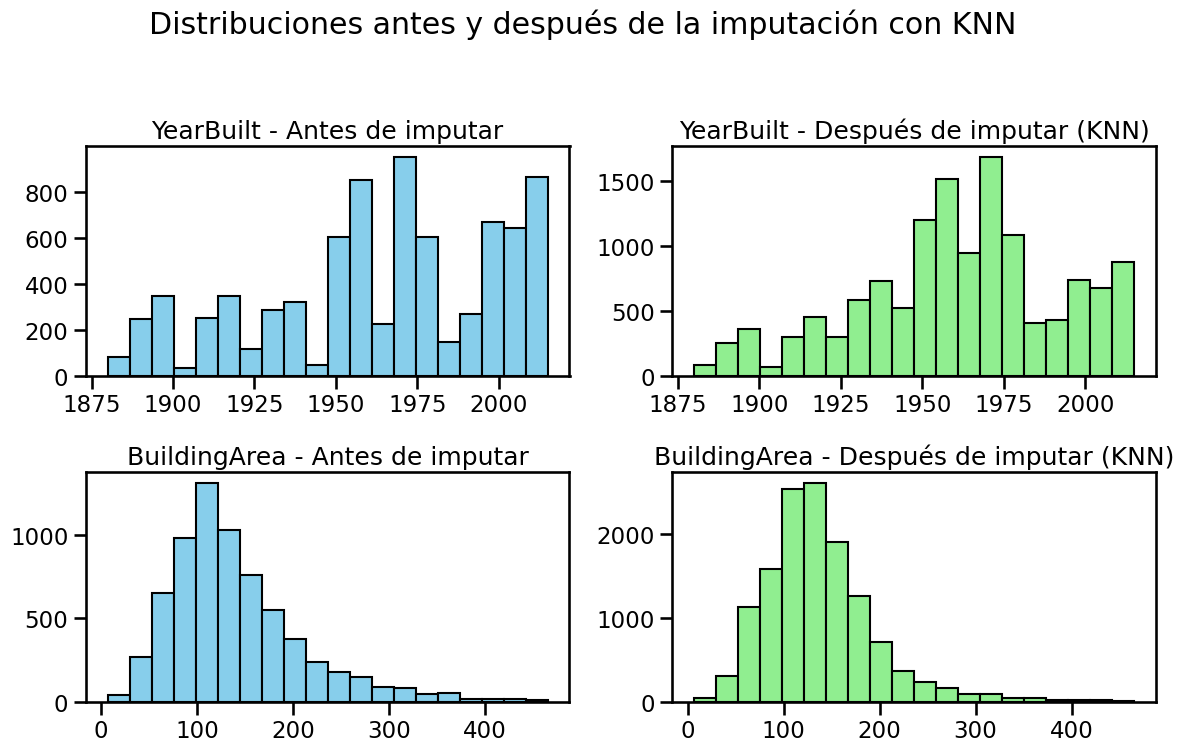

In [7]:
# Grafiquemos las distribuciones antes y después de la imputación

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Distribuciones antes y después de la imputación con KNN')

# YearBuilt antes de imputar
axes[0, 0].hist(original['YearBuilt'].dropna(), bins=20, color='skyblue', edgecolor='black')
axes[0, 0].set_title('YearBuilt - Antes de imputar')

# YearBuilt después de imputar
axes[0, 1].hist(post_knn['YearBuilt'], bins=20, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('YearBuilt - Después de imputar (KNN)')

# BuildingArea antes de imputar
axes[1, 0].hist(original['BuildingArea'].dropna(), bins=20, color='skyblue', edgecolor='black')
axes[1, 0].set_title('BuildingArea - Antes de imputar')

# BuildingArea después de imputar
axes[1, 1].hist(post_knn['BuildingArea'], bins=20, color='lightgreen', edgecolor='black')
axes[1, 1].set_title('BuildingArea - Después de imputar (KNN)')

# Ajustes finales
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Ejercicio 3: Reducción de dimensionalidad.

Utilizando la matriz obtenida en el ejercicio anterior:
1. Aplique `PCA` para obtener $n$ componentes principales de la matriz, donde `n = min(20, X.shape[0])`. ¿Es necesario estandarizar o escalar los datos?
2. Seleccione las primeras $2$ columnas de la matriz transformada para agregar como nuevas características al conjunto de datos. Realizar un gráfico de la componente principal 1 vs la componente principal 2 (pca1-pca2).
3. Transformar nuevamente el conjunto de datos procesado en un `pandas.DataFrame` y guardarlo en un archivo.

Al igual que antes, es necesario estandarizar o escalar los datos. PCA se basa en la varianza de las variables, por lo que una variable con valores numéricamente grandes puede dominar las componentes principales si se escala. De todas formas, ya hemos escalado anteriormente, por lo que el dataframe ya está listo.

In [8]:
from sklearn.decomposition import PCA

# Obtenemos el número n
n_components = min(20, result.shape[0])
# Aplicamos PCA para obtener n componentes de la matriz
pca = PCA(n_components=n_components)
pca_dummy_features = pca.fit_transform(result)

# Imprimimos el shape de la matriz PCA
print(pca_dummy_features.shape)

# Agregamos las 2 primeras columnas de la matriz al df
mice_encoded_scaled_df['pca1'] = pca_dummy_features[:, 0]
mice_encoded_scaled_df['pca2'] = pca_dummy_features[:, 1]
mice_encoded_scaled_df.head()

(13204, 20)


,Type_h,Type_u,Type_t,SellerG_Biggin,SellerG_Nelson,SellerG_Jellis,SellerG_Greg,SellerG_Marshall,SellerG_Brad,SellerG_Barry,...,Bedroom2,Bathroom,Car,Lattitude,Longtitude,Propertycount,YearBuilt,BuildingArea,pca1,pca2
0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.10,0.125,0.1,0.489698,0.517651,0.170735,0.162963,0.263755,-0.679111,0.315731
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.10,0.125,0.0,0.478867,0.513083,0.170735,0.148148,0.157205,-0.672985,0.330877
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.15,0.250,0.0,0.477041,0.513997,0.170735,0.148148,0.312227,-0.552425,0.553161
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.15,0.250,0.1,0.493221,0.516281,0.170735,0.634074,0.251092,-0.472403,0.515972
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.15,0.125,0.2,0.479781,0.513723,0.170735,0.992593,0.294760,-0.578655,0.673163


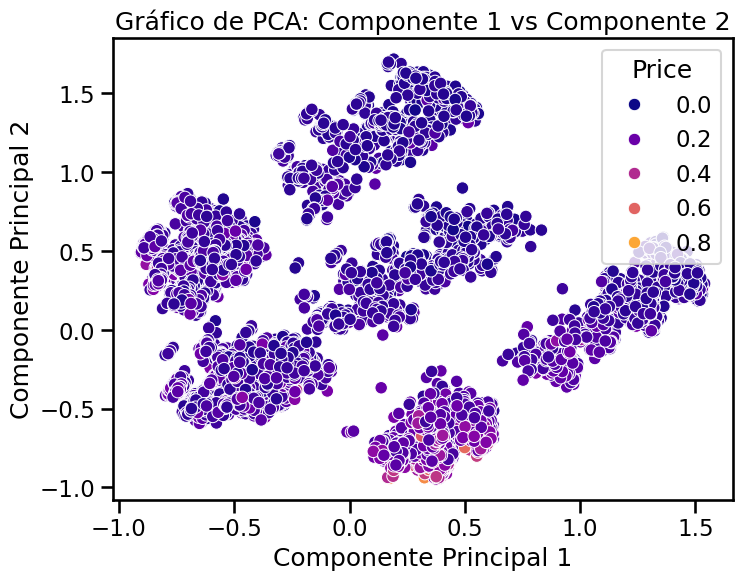

In [9]:
# Grafiquemos la componente principal 1 vs la componente principal 2
fig = plt.figure(figsize=(8, 6))
seaborn.scatterplot(data=mice_encoded_scaled_df, x='pca1', y='pca2',
                    hue='Price', palette='plasma')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Gráfico de PCA: Componente 1 vs Componente 2')
plt.show()

In [10]:
# Guardamos el DataFrame final con PCA en un archivo CSV
mice_encoded_scaled_df.to_csv("melb_data_pca.csv", index=False)

**Ejemplo de código para este problema**

In [11]:
## Ejemplo pequeño, tienen que extenderlo a su DataFrame procesada
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder

## Supongamos solo estas variables
categorical_cols = ['Type', 'Regionname']
numerical_cols = ['Rooms', 'Distance']
new_columns = []

# Paso 1: codificamos las variables categóricas
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_cat = encoder.fit_transform(melb_df[categorical_cols])
for col, col_values in zip(categorical_cols, encoder.categories_):
  for col_value in col_values:
    new_columns.append('{}={}'.format(col, col_value))
print("Matrix has shape {}, with columns: {}".format(X_cat.shape, new_columns))

# Paso 2: anexamos las variables numéricas
X = numpy.hstack([X_cat, melb_df[numerical_cols].values])
new_columns.extend(numerical_cols)
print("Matrix has shape {}, with columns: {}".format(X_cat.shape, new_columns))

# Paso 3: usamos las dos primeras componentes principales a nuestro conjunto de datos
pca = PCA(n_components=2)
pca_dummy_features = pca.fit_transform(X)
X_pca = numpy.hstack([X, pca_dummy_features])
new_columns.extend(['pca1', 'pca2'])

## Paso 4: rearmamos el datagframe (ver que al final tenemos las componentes principales)
processed_melb_df = pandas.DataFrame(data=X_pca, columns=new_columns)
processed_melb_df.head()

## Falta la parte de guardarlo en un archivo

Matrix has shape (13580, 11), with columns: ['Type=h', 'Type=t', 'Type=u', 'Regionname=Eastern Metropolitan', 'Regionname=Eastern Victoria', 'Regionname=Northern Metropolitan', 'Regionname=Northern Victoria', 'Regionname=South-Eastern Metropolitan', 'Regionname=Southern Metropolitan', 'Regionname=Western Metropolitan', 'Regionname=Western Victoria']
Matrix has shape (13580, 11), with columns: ['Type=h', 'Type=t', 'Type=u', 'Regionname=Eastern Metropolitan', 'Regionname=Eastern Victoria', 'Regionname=Northern Metropolitan', 'Regionname=Northern Victoria', 'Regionname=South-Eastern Metropolitan', 'Regionname=Southern Metropolitan', 'Regionname=Western Metropolitan', 'Regionname=Western Victoria', 'Rooms', 'Distance']


,Type=h,Type=t,Type=u,Regionname=Eastern Metropolitan,Regionname=Eastern Victoria,Regionname=Northern Metropolitan,Regionname=Northern Victoria,Regionname=South-Eastern Metropolitan,Regionname=Southern Metropolitan,Regionname=Western Metropolitan,Regionname=Western Victoria,Rooms,Distance,pca1,pca2
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,2.5,-7.669418,-0.292703
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,2.5,-7.669418,-0.292703
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,2.5,-7.620201,0.619633
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,2.5,-7.620201,0.619633
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,4.0,2.5,-7.570984,1.531969


## Ejercicio 4: Documentación

En un documento `.pdf` o `.md` realizar un reporte de las operaciones que realizaron para obtener el conjunto de datos final. Se debe incluir:
  1. Criterios de exclusión (o inclusión) de filas y de imputación de datos faltantes
  2. Interpretación de las columnas presentes
  3. Todas las transofrmaciones realizadas
  4. Análisis breve de lo observado mediante PCA.

Este documento es de uso técnico exclusivamente, y su objetivo es permitir que otres desarrolladores puedan reproducir los mismos pasos y obtener el mismo resultado. Debe ser detallado pero consiso. Por ejemplo:

```
  ## Criterios de exclusión de ejemplos
  1. Se eliminan ejemplos donde el año de construcción es previo a 1900

  ## Características seleccionadas
  ### Características categóricas
  1. Type: tipo de propiedad. 3 valores posibles
  2. ...
  Todas las características categóricas fueron codificadas con un
  método OneHotEncoding utilizando como máximo sus 30 valores más
  frecuentes.
  
  ### Características numéricas
  1. Rooms: Cantidad de habitaciones
  2. Distance: Distancia al centro de la ciudad.
  3. airbnb_mean_price: Se agrega el precio promedio diario de
     publicaciones de la plataforma AirBnB en el mismo código
     postal. [Link al repositorio con datos externos].

  ### Transformaciones:
  1. Todas las características numéricas fueron estandarizadas.
  2. La columna `Suburb` fue imputada utilizando el método ...
  3. Las columnas `YearBuilt` y ... fueron imputadas utilizando el
     algoritmo ...
  4. ...

  ### Datos aumentados
  1. Se agregan las 5 primeras columnas obtenidas a través del
     método de PCA, aplicado sobre el conjunto de datos
     totalmente procesado.
```
